# 05: Cold-Cloud Metrics (GridSat-B1)

**Q3**: Does cold-cloud-top area (BT < 208 K) differ between WNP and ATL storms in the 48 h before impact?  
**Q4**: What is the CDO radius (BT < 235 K proxy for SW dimming footprint) at each storm's peak?

For each 3-hourly GridSat-B1 file in the 96 h pre-impact window, compute:
- `cold_area_km2` — pixels with BT < 208 K, cos(lat)-weighted area  
- `cdo_area_km2`  — pixels with BT < 235 K (cirrus shield / SW-dimming footprint)  
- `min_bt_K`      — minimum BT in the storm-centred box  

**Prerequisite**: run `03_download_gridsat.py` first.  
**Outputs**: `data/gridsat/metrics_{storm}.csv`

## 1: Setup

In [1]:
import os, sys, glob, re
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import (
    GRIDSAT_DIR, IBTRACS_DIR, STORM_ORDER, STORMS,
    BT_COLD, BT_CDO, GRIDSAT_DX, R_EARTH, ensure_dirs
)

ensure_dirs()
print(f'BT_COLD threshold : {BT_COLD} K  (deep convection / OLR suppression)')
print(f'BT_CDO  threshold : {BT_CDO} K  (cirrus shield / SW dimming footprint)')

BT_COLD threshold : 208 K  (deep convection / OLR suppression)
BT_CDO  threshold : 235 K  (cirrus shield / SW dimming footprint)


## 2: Helper functions

In [2]:
def pixel_area_km2(lat_2d):
    """cos(lat)-corrected area in km² for each GridSat pixel."""
    dx_rad = GRIDSAT_DX * np.pi / 180.0
    return (dx_rad * R_EARTH) ** 2 * np.cos(np.radians(lat_2d))


def parse_nc_datetime(fpath):
    """Extract UTC timestamp from GRIDSAT-B1.YYYY.MM.DD.HH.nc filename."""
    m = re.search(r'GRIDSAT-B1\.(\d{4})\.(\d{2})\.(\d{2})\.(\d{2})', fpath)
    if not m:
        return None
    y, mo, d, h = (int(x) for x in m.groups())
    return pd.Timestamp(year=y, month=mo, day=d, hour=h, tz='UTC')


def compute_metrics(fpath):
    """Open one GridSat NetCDF and return cold-cloud metric dict."""
    try:
        ds  = xr.open_dataset(fpath, engine='netcdf4')
        bt  = ds['irwin_cdr'].squeeze().values.astype(float)
        lats = ds['lat'].values
        ds.close()
    except Exception as exc:
        print(f'  [WARN] Cannot open {os.path.basename(fpath)}: {exc}')
        return None

    lat_2d = np.broadcast_to(lats[:, None], bt.shape)
    valid  = np.isfinite(bt)
    area   = pixel_area_km2(lat_2d)

    return {
        'cold_area_km2': float(np.nansum(area[(bt < BT_COLD) & valid])),
        'cdo_area_km2':  float(np.nansum(area[(bt < BT_CDO)  & valid])),
        'min_bt_K':      float(np.nanmin(bt[valid])) if valid.any() else np.nan,
    }


print('Helper functions defined.')

Helper functions defined.


## 3: Process each storm

In [3]:
all_metrics = {}

for key in STORM_ORDER:
    nc_dir = os.path.join(GRIDSAT_DIR, key)
    track_csv = os.path.join(IBTRACS_DIR, f'{key}_track.csv')

    if not os.path.isdir(nc_dir):
        print(f'[{key}] GridSat directory missing — skipping. Run 03_download_gridsat.py first.')
        continue
    if not os.path.exists(track_csv):
        print(f'[{key}] Track CSV missing: skipping.')
        continue

    track_df  = pd.read_csv(track_csv, parse_dates=['ISO_TIME'])
    idx_min   = track_df['dist_km'].idxmin()
    t_closest = track_df.loc[idx_min, 'ISO_TIME']
    if t_closest.tzinfo is None:
        t_closest = t_closest.tz_localize('UTC')

    files  = sorted(glob.glob(os.path.join(nc_dir, 'GRIDSAT-B1.*.nc')))
    print(f'[{key}] {len(files)} GridSat files found …')

    records = []
    for fpath in files:
        dt = parse_nc_datetime(fpath)
        if dt is None:
            continue
        hours = (dt - t_closest).total_seconds() / 3600.0
        if not (-96 <= hours <= 6):
            continue
        m = compute_metrics(fpath)
        if m is None:
            continue
        m['utc_time']       = dt.isoformat()
        m['hours_to_impact'] = round(hours, 2)
        records.append(m)

    if not records:
        print(f'  [{key}] No valid files in the -96…+6 h window.')
        continue

    df_m = pd.DataFrame(records).sort_values('hours_to_impact')
    all_metrics[key] = df_m
    print(f'  [{key}] {len(df_m)} timesteps processed.  '
          f'cold_area max = {df_m["cold_area_km2"].max():.0f} km²')

[ragasa] 48 GridSat files found …
  [ragasa] 35 timesteps processed.  cold_area max = 434966 km²
[mangkhut] 46 GridSat files found …
  [mangkhut] 34 timesteps processed.  cold_area max = 485095 km²
[maria] 45 GridSat files found …
  [maria] 34 timesteps processed.  cold_area max = 156701 km²
[dorian] 43 GridSat files found …
  [dorian] 34 timesteps processed.  cold_area max = 59493 km²


## 4: Save metrics CSVs

In [4]:
for key, df_m in all_metrics.items():
    out = os.path.join(GRIDSAT_DIR, f'metrics_{key}.csv')
    df_m.to_csv(out, index=False)
    print(f'Saved: {out}')

Saved: /home/sharperace/geog_1.02_final_proj/data/gridsat/metrics_ragasa.csv
Saved: /home/sharperace/geog_1.02_final_proj/data/gridsat/metrics_mangkhut.csv
Saved: /home/sharperace/geog_1.02_final_proj/data/gridsat/metrics_maria.csv
Saved: /home/sharperace/geog_1.02_final_proj/data/gridsat/metrics_dorian.csv


## 5 — Q4: CDO area at storm peak

The CDO area (BT < 235 K) at peak intensity is the SW-dimming footprint proxy.

In [5]:
print('Q4 — CDO area (BT < 235 K) at peak intensity:')
print(f'{"Storm":30s}  {"Basin":5s}  {"CDO area at peak (km²)":>22s}  {"min BT at peak (K)":>18s}')
print('-' * 82)
for key in STORM_ORDER:
    df_m = all_metrics.get(key)
    if df_m is None:
        continue
    # Row with coldest min_bt_K ≈ peak convective intensity
    idx  = df_m['min_bt_K'].idxmin()
    cdo  = df_m.loc[idx, 'cdo_area_km2']
    minbt = df_m.loc[idx, 'min_bt_K']
    hrs  = df_m.loc[idx, 'hours_to_impact']
    name = f"{STORMS[key]['name']} ({STORMS[key]['year']})"
    print(f'{name:30s}  {STORMS[key]["basin"]:5s}  {cdo:22.0f}  {minbt:18.1f}  (at {hrs:+.0f} h)')

Q4 — CDO area (BT < 235 K) at peak intensity:
Storm                           Basin  CDO area at peak (km²)  min BT at peak (K)
----------------------------------------------------------------------------------
Ragasa (2025)                   WNP                    916256               179.3  (at -75 h)
Mangkhut (2018)                 WNP                   1736593               184.1  (at -80 h)
Maria (2017)                    ATL                    512320               185.4  (at -58 h)
Dorian (2019)                   ATL                    251919               188.8  (at -56 h)


## 6 — Q3: Cold-cloud-top area (BT < 208 K) — 48 h pre-impact comparison

Do WNP typhoons show larger or earlier cold-cloud-top area growth than ATL hurricanes?

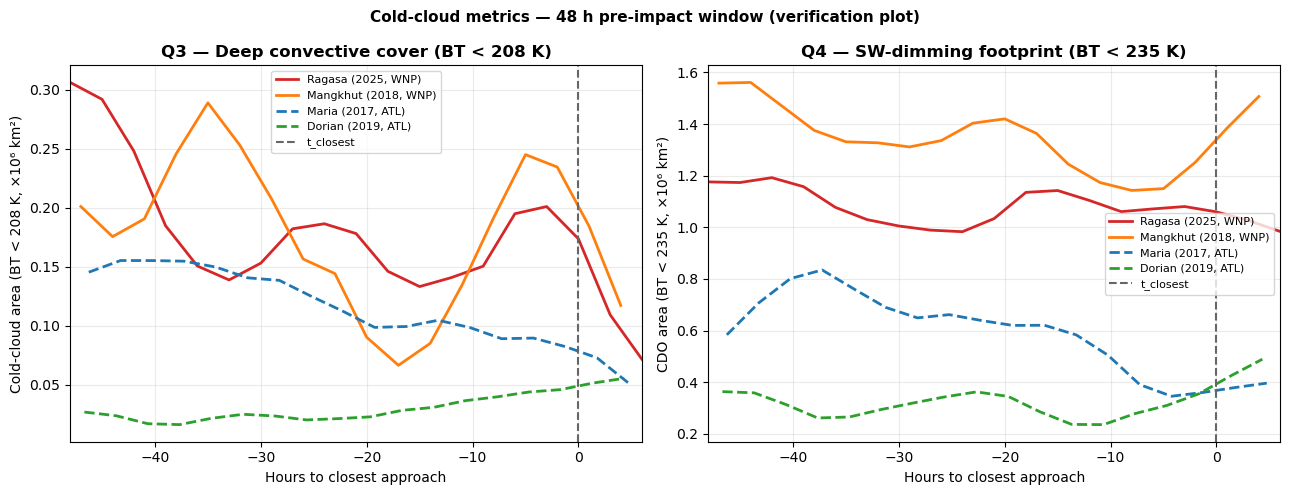

(Polished version → fig5_coldcloud_timeseries.ipynb)


In [6]:
from scipy.ndimage import uniform_filter1d

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for key in STORM_ORDER:
    df_m = all_metrics.get(key)
    if df_m is None:
        continue
    meta = STORMS[key]
    h    = df_m['hours_to_impact'].values

    # smooth with 9-h rolling mean (3 timesteps)
    cold = uniform_filter1d(df_m['cold_area_km2'].values / 1e6, size=3, mode='nearest')
    cdo  = uniform_filter1d(df_m['cdo_area_km2'].values  / 1e6, size=3, mode='nearest')

    kw = dict(color=meta['color'], linestyle=meta['linestyle'], linewidth=2,
              label=f"{meta['name']} ({meta['year']}, {meta['basin']})")

    # Q3: focus on last 48 h
    mask = (h >= -48) & (h <= 6)
    axes[0].plot(h[mask], cold[mask], **kw)
    axes[1].plot(h[mask], cdo[mask],  **kw)

for ax, ylabel, title in zip(
    axes,
    ['Cold-cloud area (BT < 208 K, ×10⁶ km²)', 'CDO area (BT < 235 K, ×10⁶ km²)'],
    ['Q3 — Deep convective cover (BT < 208 K)', 'Q4 — SW-dimming footprint (BT < 235 K)']
):
    ax.axvline(0, color='0.4', linestyle='--', label='t_closest')
    ax.set_xlim(-48, 6)
    ax.set_xlabel('Hours to closest approach')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

plt.suptitle('Cold-cloud metrics — 48 h pre-impact window (verification plot)',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()
print('(Polished version → fig5_coldcloud_timeseries.ipynb)')